<a href="https://colab.research.google.com/github/FV-Robert-Harol/SIS420-IA/blob/main/RegrecionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicion de programación - Regresión Logistica

En este ejercicio se implementa regresion logistica y se aplica a dos diferentes datasets.

In [ ]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 Regresion Logistica

En esta parte del ejercicio, creará un modelo de regresión logística para predecir si un estudiante será admitido en una universidad. Suponga que es el administrador de un departamento universitario y desea determinar las posibilidades de admisión de cada solicitante en función de sus resultados en dos exámenes. Tiene datos históricos de solicitantes anteriores que puede usar como un conjunto de capacitación para la regresión logística. Para cada ejemplo de capacitación, se tiene las calificaciones del solicitante en dos exámenes y la decisión de admisión. Su tarea es crear un modelo de clasificación que calcule la probabilidad de admisión de un solicitante en función de los puntajes de esos dos exámenes.

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [ ]:
# 1. Definir la ruta exacta de tu Drive
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/sis420/dataset/MiniBooNE_PID.txt'

# 2. Leer SOLO la primera línea para obtener la cantidad de 1s y 0s
with open(ruta_dataset, 'r') as file:
    primera_linea = file.readline().strip()
    num_senales, num_fondo = map(int, primera_linea.split())

print(f"Creando vector objetivo (y): {num_senales} señales (1) y {num_fondo} fondo (0)")

# 3. Cargar las 50 características (X)
# np.loadtxt por defecto separa por cualquier cantidad de espacios en blanco
# skiprows=1 ignora la primera línea que ya leímos
print("Cargando matriz de características (X)")
X = np.loadtxt(ruta_dataset, skiprows=1)

# 4. Crear el vector objetivo (y)
y = np.array([1] * num_senales + [0] * num_fondo)

# 5. Imprimir para verificar que todo cuadra con tu código posterior
print("Dimensiones de X:", X.shape) # Debería ser (130064, 50)
print(X)
print("Dimensiones de y:", y.shape) # Debería ser (130064,)
print(y)

Creando vector objetivo (y): 36499 señales (1) y 93565 fondo (0)
Cargando matriz de características (X)... esto puede tardar unos segundos.
Dimensiones de X: (130064, 50)
[[2.59413e+00 4.68803e-01 2.06916e+01 ... 4.57585e-01 7.17692e-02
  2.45996e-01]
 [3.86388e+00 6.45781e-01 1.81375e+01 ... 9.35523e-01 3.33613e-01
  2.30621e-01]
 [3.38584e+00 1.19714e+00 3.60807e+01 ... 1.01345e+00 2.55512e-01
  1.80901e-01]
 ...
 [3.10842e+00 2.17814e+00 5.63651e+01 ... 7.89276e-01 7.30342e-01
  1.52876e-01]
 [5.44560e+00 1.84570e+00 1.03463e+02 ... 2.87259e+00 8.19867e-01
  2.10619e-01]
 [4.55062e+00 1.34174e+00 8.00887e+01 ... 2.64744e+00 7.42709e-01
  2.76477e-01]]
Dimensiones de y: (130064,)
[1 1 1 ... 0 0 0]


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [ ]:
# Definimos la función adaptada para manejar los colores y transparencia
def plotData(X_plot, y_plot):
    # Encontramos los índices donde y es 1 (señal) y 0 (fondo)
    pos = y_plot == 1
    neg = y_plot == 0

    # Graficamos usando alpha=0.5 para dar transparencia y ver la densidad
    pyplot.plot(X_plot[pos, 0], X_plot[pos, 1], 'b+', lw=2, ms=8, alpha=0.6)
    pyplot.plot(X_plot[neg, 0], X_plot[neg, 1], 'ro', mfc='y', ms=6, mec='k', alpha=0.4)


Se llama a la función implementada para mostrar los datos cargados:

Las variables más relacionadas con la aparición de un electrón son las columnas: 15 y 22


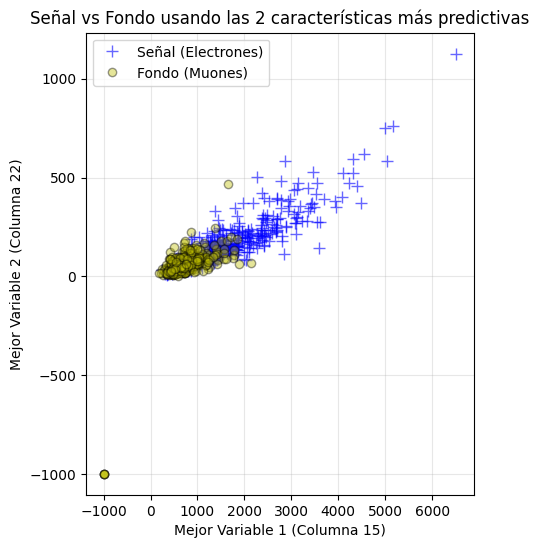

In [ ]:
import warnings
warnings.filterwarnings("ignore") # Para evitar advertencias si alguna columna es constante

# 1. Encontrar automáticamente las 2 mejores variables (mayor correlación con y)
correlaciones = []
for i in range(X.shape[1]):
    # Calculamos la correlación entre la columna i y el vector y
    corr = np.corrcoef(X[:, i], y)[0, 1]
    # Guardamos el valor absoluto (nos importan correlaciones fuertes, sean positivas o negativas)
    correlaciones.append(abs(corr) if not np.isnan(corr) else 0)

# Obtenemos los índices de las 2 características con la correlación más alta
mejores_indices = np.argsort(correlaciones)[-2:]
col_mejor_1 = mejores_indices[1] # La #1 con más relación
col_mejor_2 = mejores_indices[0] # La #2 con más relación

print(f"Las variables más relacionadas con la aparición de un electrón son las columnas: {col_mejor_1} y {col_mejor_2}")

# =======================================================
# CÓDIGO PARA LLAMAR A LA GRÁFICA CON LAS MEJORES VARIABLES
# =======================================================

# Tomamos una muestra para no saturar la imagen (500 de clase 1, 500 de clase 0)
indices_clase_1 = np.where(y == 1)[0][:500]
indices_clase_0 = np.where(y == 0)[0][:500]
indices_muestra = np.concatenate([indices_clase_1, indices_clase_0])

# Filtramos X usando la muestra, y tomamos EXCLUSIVAMENTE las 2 mejores columnas
X_muestra = X[indices_muestra][:, [col_mejor_1, col_mejor_2]]
y_muestra = y[indices_muestra]

# Llamamos a tu función plotData (asegúrate de que la función plotData ya esté definida arriba)
pyplot.figure(figsize=(5,6 ))
plotData(X_muestra, y_muestra)

# Adicionamos etiquetas dinámicas
pyplot.xlabel(f'Mejor Variable 1 (Columna {col_mejor_1})')
pyplot.ylabel(f'Mejor Variable 2 (Columna {col_mejor_2})')

# Leyenda y título
pyplot.legend(['Señal (Electrones)', 'Fondo (Muones)'], loc='best')
pyplot.title('Señal vs Fondo usando las 2 características más predictivas')
pyplot.grid(True, alpha=0.3)
pyplot.show()

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea

La hipotesis para la regresión logistica se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ is la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la funcion sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluacion de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta funcion tambien debe poder trabajar con vectores y matrices.

In [ ]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Evitamos dividir por cero en caso de columnas constantes
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [ ]:
print("Normalizando las características...")
X_norm, mu, sigma = featureNormalize(X)
print(X_norm)

Normalizando las características...
[[ 0.02232761  0.04300168 -0.5260113  ...  0.02003611  0.03434471
   0.06034894]
 [ 0.04344796  0.04595561 -0.53904177 ...  0.02799921  0.03871271
   0.06009197]
 [ 0.03549649  0.05515829 -0.44749947 ...  0.02929758  0.03740985
   0.05926097]
 ...
 [ 0.03088204  0.07153207 -0.34401287 ...  0.02556253  0.04533082
   0.05879257]
 [ 0.06975744  0.06598334 -0.10372964 ...  0.06027338  0.04682425
   0.05975766]
 [ 0.05487082  0.05757179 -0.22298023 ...  0.05652208  0.04553712
   0.06085839]]


<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [ ]:
m, n = X_norm.shape
X_entrenamiento = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

La funcion de costo en una regresión logistica es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>

In [ ]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

Iniciando descenso por el gradiente... (puede tomar unos segundos)


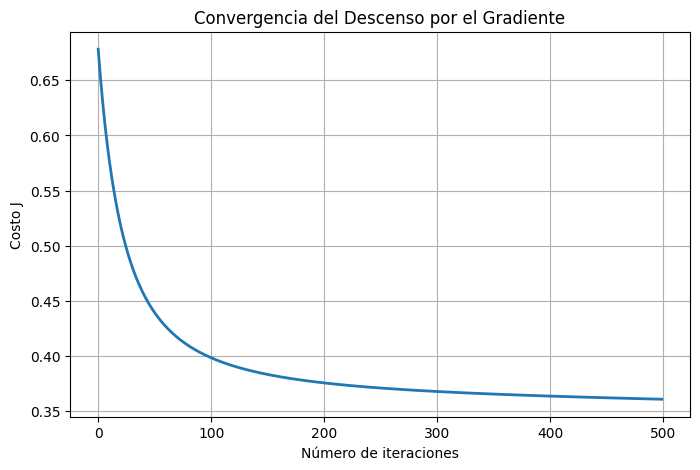

In [ ]:
# Usamos un alpha de 0.1 que funciona muy bien con datos normalizados
alpha = 0.1
num_iters = 500
theta_inicial = np.zeros(X_entrenamiento.shape[1])

print("Iniciando descenso por el gradiente... (puede tomar unos segundos)")
theta_optimo, J_history = descensoGradiente(theta_inicial, X_entrenamiento, y, alpha, num_iters)

# Graficar la convergencia
pyplot.figure(figsize=(8,5))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)
pyplot.show()

In [ ]:
print('valores de theta calculados: ', theta_optimo)

# Prueba con la Fila 0 (Sabemos que es Señal)
prob_senial = sigmoid(np.dot(X_entrenamiento[0], theta_optimo))
print(f'\nProbabilidad de ser Señal (Fila 0, real = 1): {prob_senial * 100:.2f}%')

# Prueba con la Última Fila (Sabemos que es Fondo)
prob_fondo = sigmoid(np.dot(X_entrenamiento[-1], theta_optimo))
print(f'Probabilidad de ser Señal (Última fila, real = 0): {prob_fondo * 100:.2f}%')

valores de theta calculados:  [-1.13741028 -0.06864229  0.01242019 -0.17425167  0.02403233  0.02759581
  0.03479862  0.04936728  0.02976152  0.01693756  0.03044428  0.02415425
 -0.2225931   0.00794508  0.01855295  0.040344    1.3343382   0.04081361
 -0.45686892  0.02806908 -0.00509509  0.10916658  0.02774585  0.841417
  0.07951064  0.0302202   0.10936123 -0.93902711  0.01421401  0.02589174
  0.04382819 -0.09255601  0.0557453  -0.0036166  -0.28259817  0.02940135
  0.03142808  0.07494143 -0.01594936  0.02182028  0.02667951 -0.69118598
  0.68061461  0.04530354 -0.14433782  0.02657785  0.02473636  0.05259579
 -0.04847812 -0.04434178  0.02798779]

Probabilidad de ser Señal (Fila 0, real = 1): 85.56%
Probabilidad de ser Señal (Última fila, real = 0): 17.90%


In [ ]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

Se prueba la funcion `costFunction` utilizando dos casos de prueba para

*   Elemento de lista
*   Elemento de lista

In [ ]:
# Inicializacion de parametros de ajuste
# Asegúrate de que 'n' sea 50 (el número de columnas originales de tu dataset)
initial_theta = np.zeros(n + 1)
print(initial_theta)

cost, grad = costFunction(initial_theta, X_entrenamiento, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Costo esperado (aproximado): 0.693\n')
print(grad)

print('Gradiente en theta inicial (zeros):')
# Creamos dinámicamente el formato para imprimir los 51 valores sin error
formato_string = '\t[' + ', '.join(['{:.4f}'] * len(grad)) + ']'
print(formato_string.format(*grad))

print('\nGradiente esperado (aproximado):')
print('\t(No hay un gradiente esperado fijo, los valores calculados arriba son los correctos para tu dataset)\n')



[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Costo esperado (aproximado): 0.693

[ 0.21937661 -0.0107199  -0.01297474 -0.04171338 -0.01528498 -0.01547463
 -0.01582832 -0.01648548 -0.01565043 -0.01486164 -0.01556192 -0.01533833
  0.01348598 -0.01587394 -0.01522945 -0.01777254 -0.23037019 -0.01722041
  0.01045869 -0.01544684  0.00075423 -0.01788576 -0.01551825 -0.17955759
 -0.0171675  -0.01560789 -0.01832405  0.08675698 -0.01472082 -0.01536345
 -0.01649972 -0.00943212 -0.01671387 -0.0136317   0.0050768  -0.01556148
 -0.01555742 -0.01770028 -0.0124655  -0.01551735 -0.01542932 -0.00951768
 -0.07738091 -0.0149755  -0.0088263  -0.01542138 -0.01533711 -0.01617936
 -0.01039888 -0.01124975 -0.01548623]
Gradiente en theta inicial (zeros):
	[0.2194, -0.0107, -0.0130, -0.0417, -0.0153, -0.0155, -0.0158, -0.0165, -0.0157, -0.0149, -0.0156, -0.0153, 0.

In [ ]:
# Creamos test_theta con 51 valores: el primero (intercepción) en -24 y los 50 restantes en 0.2
test_theta = np.ones(X_entrenamiento.shape[1]) * 0.2
test_theta[0] = -24

print(test_theta)
cost, grad = costFunction(test_theta, X_entrenamiento, y)

print('Costo en theta prueba: {:.3f}'.format(cost))
print('Costo esperado (aproximado): (Es tu dataset, el de arriba es el real)\n')

print('Gradiente en theta prueba:')
# Generamos los 51 espacios '{:.3f}' dinámicamente para que no falle al imprimir
formato_string = '\t[' + ', '.join(['{:.3f}'] * len(grad)) + ']'
print(formato_string.format(*grad))

print('\nGradiente esperado (aproximado):')
print('\t(Al ser tu propio dataset, los valores de arriba son los correctos)')

[-24.    0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2
   0.2   0.2   0.2]
Costo en theta prueba: inf
Costo esperado (aproximado): (Es tu dataset, el de arriba es el real)

Gradiente en theta prueba:
	[-0.281, -0.011, -0.013, -0.042, -0.015, -0.015, -0.016, -0.016, -0.016, -0.015, -0.016, -0.015, 0.013, -0.016, -0.015, -0.018, -0.230, -0.017, 0.010, -0.015, 0.004, -0.018, -0.016, -0.180, -0.017, -0.016, -0.018, 0.087, -0.015, -0.015, -0.016, -0.009, -0.017, -0.014, 0.005, -0.016, -0.016, -0.018, -0.012, -0.016, -0.015, -0.010, -0.077, -0.015, -0.009, -0.015, -0.015, -0.016, -0.010, -0.011, -0.015]

Gradiente esperado (aproximado):
	(Al ser tu propio dataset, los valores de arriba son los correctos)


#### 1.2.3 Parámetros de aprendizaje usando `scipy.optimize`

En el codigo anterior se encontró los parámetros óptimos de un modelo de regresión lineal al implementar el descenso de gradiente. Se implemento una función de costo y se calculó su gradiente, utilizando el algoritmo del descenso por el gradiente.

En lugar de realizar los pasos del descenso por el gradiente, se utilizará el [módulo `scipy.optimize`] (https://docs.scipy.org/doc/scipy/reference/optimize.html). SciPy es una biblioteca de computación numérica para `python`. Proporciona un módulo de optimización para la búsqueda y minimización de raíces. A partir de `scipy 1.0`, la función` scipy.optimize.minimize` es el método a utilizar para problemas de optimización (tanto restringidos como no restringidos).

For logistic regression, you want to optimize the cost function $J(\theta)$ with parameters $\theta$.
Concretely, you are going to use `optimize.minimize` to find the best parameters $\theta$ for the logistic regression cost function, given a fixed dataset (of X and y values). You will pass to `optimize.minimize` the following inputs:

Para la regresión logística, se desea optimizar la función de costo $J(\theta)$ con los parámetros $\theta$.
Concretamente, se va a utilizar `optimize.minimize` para encontrar los mejores parámetros $\theta$ para la función de costo de regresión logística, dado un dataset fijo (de valores X e y). Se pasara a `optimize.minimize` las siguientes entradas:

- `costFunction`: Una función de costo que, cuando se le da el dataset de entrenamiento y un $\theta$ particular, calcula el costo de regresión logística y el gradiente con respecto a $\theta$ para el dataset(X, y). Es importante tener en cuenta que solo se pasa el nombre de la función sin el paréntesis. Esto indica que solo proporcionamos una referencia a esta función y no evaluamos el resultado de esta función.
- `initial_theta`: Los valores iniciales de los parametros que se tratan de optimizar.
- `(X, y)`: Estos son argumentos adicionales a la funcion de costo.
- `jac`: Indicación si la función de costo devuelve el jacobiano (gradiente) junto con el valor de costo. (True)
- `method`: Método / algoritmo de optimización a utilizar
- `options`: Opciones adicionales que pueden ser específicas del método de optimización específico. Solo se indica al algoritmo el número máximo de iteraciones antes de que termine.

Si se ha completado la `costFunction` correctamente,`optimize.minimize` convergerá en los parámetros de optimización correctos y devolverá los valores finales del costo y $\theta$ en un objeto de clase.

Al usar `optimize.minimize`, no se tuvo que escribir ningún bucle ni establecer una tasa de aprendizaje como se hizo para el descenso de gradientes. Todo esto se hace mediante `optimize.minimize`: solo se necesita proporcionar una función que calcule el costo y el gradiente.

A continuación, se tiene el código para llamar a `optimize.minimize` con los argumentos correctos.

In [ ]:
# Establecer las opciones para optimize.minimize
# Le damos hasta 1000 iteraciones al optimizador para que encuentre el mínimo
options= {'maxiter': 1000}

# revisar la documentacion de scipy's optimize.minimize para mayor descripcion de los parametros
# La funcion devuelve un objeto `OptimizeResult`
# Se utiliza el algoritmo de Newton truncado (TNC) para la optimización.
res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_entrenamiento, y),
                        jac=True,
                        method='TNC',
                        options=options)

# la propiedad fun del objeto devuelto por `OptimizeResult`
# contiene el valor del costFunction de un theta optimizado
cost = res.fun

# Theta optimizada esta en la propiedad x
theta = res.x

# Imprimir theta en la pantalla
print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))
print('Costo esperado: (El valor calculado arriba es el mínimo real para tu dataset)\n')

print('theta óptimo encontrado:')
# Generamos dinámicamente el formato para imprimir los 51 valores de theta
formato_string = '\t[' + ', '.join(['{:.3f}'] * len(theta)) + ']'
print(formato_string.format(*theta))

print('\nTheta esperado (aproximado):')
print('\t(¡No hay un theta esperado en un dataset propio! Estos 51 valores son tus pesos finales.)')

Costo con un valor de theta encontrado por optimize.minimize: 0.318
Costo esperado: (El valor calculado arriba es el mínimo real para tu dataset)

theta óptimo encontrado:
	[-1.521, -10.414, 0.856, -0.217, 0.052, 0.605, 1.497, 3.119, 0.625, -0.787, 0.957, 0.479, -0.390, -6.110, -0.020, -0.060, 0.907, 0.545, -0.593, 0.407, 0.046, 7.223, 0.478, 1.478, 1.280, 0.922, 4.231, -0.537, -0.464, 0.360, 3.196, -8.220, 4.266, -1.621, -0.930, 0.696, 1.111, 5.228, -1.672, -0.180, 0.597, -1.408, 0.491, 2.338, -6.413, 0.520, 0.551, 1.777, 0.014, -6.806, 0.488]

Theta esperado (aproximado):
	(¡No hay un theta esperado en un dataset propio! Estos 51 valores son tus pesos finales.)


Una vez que se completa `optimize.minimize`, se usa el valor final de $\theta$ para visualizar el límite de decisión en los datos de entrenamiento.

Para hacerlo, se implementa la función `plotDecisionBoundary` para trazar el límite de decisión sobre los datos de entrenamiento.

In [ ]:
def plotDecisionBoundary(plotData, theta, X, y):
    """
    Grafica los puntos X y Y en una nueva figura con un limite de desicion definido por theta.
    Adaptado para un dataset de múltiples variables reales (como MiniBooNE).
    """
    # hacer que theta sea un arreglo numpy
    theta = np.array(theta)

    # Como tienes 50 variables, elegimos la columna 1 y 2 para graficar esta "rebanada" 2D
    # (¡Puedes cambiar estos números si quieres ver cómo se comporta con otras columnas!)
    col_x1 = 1
    col_x2 = 2

    # Graficar los datos de muestra pasándole solo las dos columnas elegidas
    # (Asumiendo que plotData ya está definida arriba y grafica los puntos)
    plotData(X[:, [col_x1, col_x2]], y)

    if X.shape[1] <= 3:
        # Esto solo se ejecutaría si tuvieras 2 variables + intercepción
        plot_x = np.array([np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2])
        plot_y = (-1. / theta[2]) * (theta[1] * plot_x + theta[0])
        pyplot.plot(plot_x, plot_y)
        pyplot.legend(['Admitido', 'No admitido', 'Limite de decisión'])

    else:
        # ESTE ES EL BLOQUE QUE SE EJECUTARÁ PARA TU DATASET (51 columnas)

        # Rango de la grilla: como los datos están normalizados, casi todo cae entre -3 y 3
        u = np.linspace(-3, 3, 50)
        v = np.linspace(-3, 3, 50)

        z = np.zeros((u.size, v.size))

        # Evalua z = theta*X sobre la grilla
        for i, ui in enumerate(u):
            for j, vj in enumerate(v):
                # Creamos un evento "promedio" (todo ceros, que es la media al estar normalizado)
                features = np.zeros(X.shape[1])
                features[0] = 1        # Columna de intercepción
                features[col_x1] = ui  # Variable del eje X de la gráfica
                features[col_x2] = vj  # Variable del eje Y de la gráfica

                # Calculamos el producto punto de este evento inventado con tus pesos óptimos
                z[i, j] = np.dot(features, theta)

        z = z.T  # importante transponer z antes de llamar al contorno

        # Trazar la línea donde z = 0 (Ese es el límite de decisión exacto del 50%)
        pyplot.contour(u, v, z, levels=[0], linewidths=2, colors='green')

        # Etiquetas adaptadas
        pyplot.legend(['Señal (Electrón)', 'Fondo (Muón)', 'Límite de decisión'])
        pyplot.xlabel(f'Variable Física Normalizada {col_x1}')
        pyplot.ylabel(f'Variable Física Normalizada {col_x2}')
        pyplot.title('Límite de decisión (Rebanada 2D de las variables 1 y 2)')

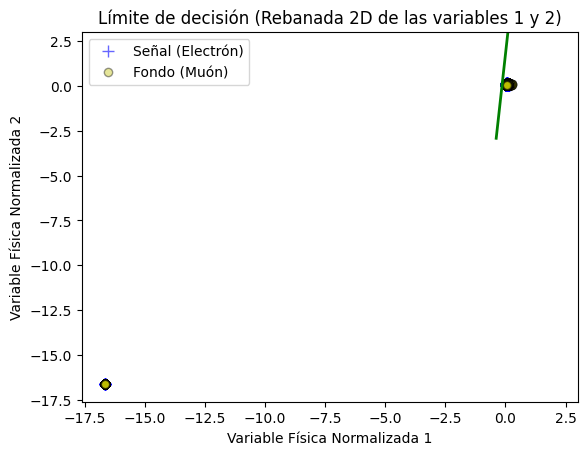

In [ ]:
# Graficar limites
plotDecisionBoundary(plotData, theta, X_entrenamiento, y)

<a id="section4"></a>
#### 1.2.4 Evaluación de la regresión logistica

Después de aprender los parámetros, se puede usar el modelo para predecir si un estudiante en particular será admitido. Para un estudiante con una puntuación en el Examen 1 de 45 y una puntuación en el Examen 2 de 85, debe esperar ver una probabilidad de admisión de 0,776. Otra forma de evaluar la calidad de los parámetros que hemos encontrado es ver qué tan bien predice el modelo aprendido en nuestro conjunto de entrenamiento.

In [ ]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 (Fondo/Muón) o 1 (Señal/Electrón) mediante la regresión logística aprendida.
    Calcula las predicciones para X usando un umbral de 0.5
    (es decir, si la probabilidad calculada por la sigmoide es >= 0.5, predice 1).

    Parametros
    ----------
    theta : array_like
        Parametros óptimos encontrados para la regresión logística. Un vector de 51 dimensiones (n+1, ).

    X : array_like
        Datos utilizados para el cálculo de las predicciones.
        Las filas son el número de eventos del sensor,
        y las columnas son las características (1 intercepción + 50 variables físicas).

    Devuelve
    -------
    p : array_like
        Predicciones con valor 0 o 1 para cada fila (evento) en X.
    """
    m = X.shape[0] # Numero de ejemplos a predecir

    p = np.zeros(m)

    # Redondea el resultado de la sigmoide:
    # Valores >= 0.5 se vuelven 1 (Señal)
    # Valores < 0.5 se vuelven 0 (Fondo)
    p = np.round(sigmoid(X.dot(theta.T)))

    return p

Una vez entrenado el modelo se procede a realizar la prediccion y evaluación de los resultados de predecir cual es el valor que vota el modelo para todos los datos utilizados en el entrenamiento.

In [ ]:
# 1. PRUEBA INDIVIDUAL: Predice la probabilidad para un evento específico
# Usamos el primer evento de nuestro dataset (Fila 0), el cual ya está normalizado y tiene el 1 inicial.
prob = sigmoid(np.dot(X_entrenamiento[0], theta))

print('Para el primer evento registrado por el sensor, se predice una probabilidad de ser Electrón de: {:.3f}'.format(prob))
# Puedes comprobar si el modelo acertó imprimiendo la etiqueta real:
print(f'Valor real de este evento en el dataset (y[0]): {y[0]}\n')

# 2. EVALUACIÓN GLOBAL: Calcula la precisión en todo el conjunto de entrenamiento
# Usamos tu matriz X_entrenamiento que ya tiene 51 columnas
p = predict(theta, X_entrenamiento)

# Comparamos las predicciones (p) con las etiquetas reales (y)
precision = np.mean(p == y) * 100

print('Precisión de entrenamiento: {:.2f} %'.format(precision))
print('Precisión esperada (aproximadamente para el dataset MiniBooNE): ~ 85.00% - 90.00%')

Para el primer evento registrado por el sensor, se predice una probabilidad de ser Electrón de: 0.936
Valor real de este evento en el dataset (y[0]): 1

Precisión de entrenamiento: 86.68 %
Precisión esperada (aproximadamente para el dataset MiniBooNE): ~ 85.00% - 90.00%
